# Multi-Task Molecular Property Prediction
### Solubility (LogS) &bull; Blood-Brain Barrier Permeability (BBB) &bull; Toxicity (Tox21)

This notebook extends the original single-property solubility model into a **multi-task neural network**
that predicts three properties from a molecule's SMILES string at once, sharing one learned representation:

| Task | Type | Source dataset | Size |
|---|---|---|---|
| Aqueous solubility (LogS) | Regression | AqSolDB (Sorkun et al., 2019) | 9,982 compounds |
| Blood-brain barrier permeability | Binary classification | BBBP (MoleculeNet) | ~2,000 compounds |
| Toxicity (aggregated Tox21 assays) | Binary classification | Tox21 (12 assays) | ~7,800 compounds |

Combined, after de-duplication, this gives **~16,000 unique molecules** to train on &mdash; roughly
**14&times; more data** than the original 1,128-molecule Delaney/ESOL set.

Because the three datasets barely overlap (a molecule usually has *one* of the three labels, not all three),
we train the network with a **masked multi-task loss**: each output head only contributes to the loss for
the molecules that actually have that label. This is the standard approach for sparse multi-task
molecular property prediction (as used in MoleculeNet-style benchmarks).


## 1. Setup

In [1]:
# If a package is missing, uncomment and run:
# %pip install rdkit scikit-learn torch pandas numpy matplotlib joblib

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, Crippen

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, roc_auc_score, confusion_matrix

import joblib

RDLogger_disabled = True
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")   # silence RDKit's SMILES parsing warnings

os.makedirs("../data", exist_ok=True)
os.makedirs("../models", exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


## 2. Download the raw datasets

All three are small enough to fetch directly from public GitHub mirrors. If you already have them
saved locally (e.g. re-running this notebook), the download is skipped.


In [2]:
DATA_URLS = {
    "aqsoldb_raw.csv": "https://raw.githubusercontent.com/mcsorkun/AqSolDB/master/results/data_curated.csv",
    "bbbp_raw.csv":    "https://raw.githubusercontent.com/dasdibye/bbbpDL/master/BBBP.csv",
    "tox21_raw.csv.gz":"https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/tox21.csv.gz",
}

for fname, url in DATA_URLS.items():
    path = os.path.join("../data", fname)
    if not os.path.exists(path):
        print("Downloading", fname, "...")
        urllib.request.urlretrieve(url, path)
    else:
        print(fname, "already present, skipping download")

# tox21 ships gzipped -- decompress once
import gzip, shutil
tox_gz = "../data/tox21_raw.csv.gz"
tox_csv = "../data/tox21_raw.csv"
if os.path.exists(tox_gz) and not os.path.exists(tox_csv):
    with gzip.open(tox_gz, "rb") as f_in, open(tox_csv, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

print("Done.")


Done.


## 3. Molecular descriptors

We compute the same lightweight RDKit descriptors used by the original model, plus three extra ones
that are known to matter for BBB permeability and toxicity risk (aromatic ring count, molar refractivity,
heteroatom count). This keeps the feature set small, fast, and easy to reproduce for inference in the
Flask app later.


In [3]:
FEATURES = [
    "Molecular_Weight", "LogP", "TPSA", "H_Bond_Donors", "H_Bond_Acceptors",
    "Rotatable_Bonds", "Ring_Count", "Heavy_Atom_Count", "Fraction_CSP3",
    "Aromatic_Rings", "Molar_Refractivity", "Num_Heteroatoms",
]

def calc_descriptors(smiles):
    """SMILES -> dict of descriptors, or None if the SMILES is invalid."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        "canonical_smiles": Chem.MolToSmiles(mol),
        "Molecular_Weight": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "H_Bond_Donors": Lipinski.NumHDonors(mol),
        "H_Bond_Acceptors": Lipinski.NumHAcceptors(mol),
        "Rotatable_Bonds": Lipinski.NumRotatableBonds(mol),
        "Ring_Count": Lipinski.RingCount(mol),
        "Heavy_Atom_Count": Lipinski.HeavyAtomCount(mol),
        "Fraction_CSP3": Lipinski.FractionCSP3(mol),
        "Aromatic_Rings": Lipinski.NumAromaticRings(mol),
        "Molar_Refractivity": Crippen.MolMR(mol),
        "Num_Heteroatoms": Lipinski.NumHeteroatoms(mol),
    }


### 3.1 Solubility &mdash; AqSolDB (9,982 compounds)

In [4]:
aq = pd.read_csv("../data/aqsoldb_raw.csv")
print("AqSolDB raw:", aq.shape)

rows = []
for smi, sol in zip(aq["SMILES"], aq["Solubility"]):
    d = calc_descriptors(smi)
    if d is None:
        continue
    d["LogS"] = sol
    rows.append(d)

aq_feat = pd.DataFrame(rows).drop_duplicates(subset="canonical_smiles")
print("Usable after descriptor calculation + de-dup:", aq_feat.shape)
aq_feat.head()


AqSolDB raw: (9982, 26)


Usable after descriptor calculation + de-dup: (9980, 14)


,canonical_smiles,Molecular_Weight,LogP,TPSA,H_Bond_Donors,H_Bond_Acceptors,Rotatable_Bonds,Ring_Count,Heavy_Atom_Count,Fraction_CSP3,Aromatic_Rings,Molar_Refractivity,Num_Heteroatoms,LogS
0,CCCCCCCCCCCCCCCCCC[N+](C)(C)C.[Br-],392.510,3.9581,0.00,0,0,17,0,23,1.000000,0,102.4454,2,-3.616127
1,O=C1Nc2cccc3cccc1c23,169.183,2.4055,29.10,1,1,0,3,13,0.000000,2,51.9012,2,-3.254767
2,O=Cc1ccc(Cl)cc1,140.569,2.1525,17.07,0,1,1,1,9,0.000000,1,36.8395,2,-2.177078
3,CC(c1ccccc1)c1cc(C(=O)[O-])c(O)c(C(C)c2ccccc2)...,756.226,8.1161,120.72,2,6,10,6,53,0.173913,6,200.7106,7,-3.924409
4,c1cc(N(CC2CO2)CC2CO2)ccc1Cc1ccc(N(CC2CO2)CC2CO...,422.525,2.4854,56.60,0,6,12,6,31,0.520000,2,119.0760,6,-4.662065


### 3.2 Blood-brain barrier permeability &mdash; BBBP

In [5]:
bbbp = pd.read_csv("../data/bbbp_raw.csv")
print("BBBP raw:", bbbp.shape)

rows = []
for smi, label in zip(bbbp["smiles"], bbbp["p_np"]):
    d = calc_descriptors(smi)
    if d is None:
        continue
    d["BBB"] = label   # 1 = crosses the blood-brain barrier, 0 = does not
    rows.append(d)

bbbp_feat = pd.DataFrame(rows).drop_duplicates(subset="canonical_smiles")
print("Usable after descriptor calculation + de-dup:", bbbp_feat.shape)
bbbp_feat.head()


BBBP raw: (2039, 4)


Usable after descriptor calculation + de-dup: (1975, 14)


,canonical_smiles,Molecular_Weight,LogP,TPSA,H_Bond_Donors,H_Bond_Acceptors,Rotatable_Bonds,Ring_Count,Heavy_Atom_Count,Fraction_CSP3,Aromatic_Rings,Molar_Refractivity,Num_Heteroatoms,BBB
0,CC(C)NCC(O)COc1cccc2ccccc12.[Cl],294.802,3.26700,41.49,2,3,6,2,20,0.375000,2,84.4415,4,1
1,CC(C)(C)OC(=O)CCCc1ccc(N(CCCl)CCCl)cc1,360.325,4.63500,29.54,0,3,9,1,23,0.611111,1,98.8780,5,1
2,CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23,361.373,1.54400,75.01,1,5,2,4,26,0.444444,2,95.0413,8,1
3,CC(=O)NCCCOc1cccc(CN2CCCCC2)c1,290.407,2.57750,41.57,1,3,7,2,21,0.588235,1,84.3657,4,1
4,Cc1onc(-c2ccccc2Cl)c1C(=O)N[C@@H]1C(=O)N2[C@@H...,435.889,2.54872,112.74,2,6,4,4,29,0.368421,2,106.6680,10,1


### 3.3 Toxicity &mdash; Tox21

Tox21 provides 12 separate toxicity assay results per molecule (nuclear receptor and stress-response panels),
each 0/1/missing. To keep this a single binary head, we collapse them into one **aggregate toxicity flag**:
a molecule is labeled toxic if it triggered *any* assay, and non-toxic only if it has at least one
assay result and none of them fired.


In [6]:
tox = pd.read_csv("../data/tox21_raw.csv")
print("Tox21 raw:", tox.shape)

assay_cols = [c for c in tox.columns if c not in ("mol_id", "smiles")]
print("Assays:", assay_cols)

def aggregate_toxicity(row):
    vals = row[assay_cols].dropna()
    if len(vals) == 0:
        return np.nan
    return 1.0 if vals.max() >= 1 else 0.0

tox["Toxic"] = tox.apply(aggregate_toxicity, axis=1)
tox = tox.dropna(subset=["Toxic"])

rows = []
for smi, label in zip(tox["smiles"], tox["Toxic"]):
    d = calc_descriptors(smi)
    if d is None:
        continue
    d["Toxic"] = label
    rows.append(d)

tox_feat = pd.DataFrame(rows).drop_duplicates(subset="canonical_smiles")
print("Usable after descriptor calculation + de-dup:", tox_feat.shape)
tox_feat.head()


Tox21 raw: (8014, 14)
Assays: ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']


Usable after descriptor calculation + de-dup: (7823, 14)


,canonical_smiles,Molecular_Weight,LogP,TPSA,H_Bond_Donors,H_Bond_Acceptors,Rotatable_Bonds,Ring_Count,Heavy_Atom_Count,Fraction_CSP3,Aromatic_Rings,Molar_Refractivity,Num_Heteroatoms,Toxic
0,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,258.324,1.34240,82.28,1,5,3,2,16,0.222222,2,62.1622,7,1.0
1,CCN1C(=O)NC(c2ccccc2)C1=O,204.229,1.29940,49.41,1,2,2,2,15,0.272727,1,55.1017,4,0.0
2,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...,288.475,5.09030,20.23,1,1,1,4,21,0.900000,0,86.9438,1,0.0
3,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C,276.424,3.75244,32.34,1,2,7,1,20,0.588235,1,86.1627,3,0.0
4,CC(O)(P(=O)(O)O)P(=O)(O)O,206.027,-0.99220,135.29,5,3,2,0,11,1.000000,0,34.7120,9,0.0


## 4. Build the combined multi-task table

We outer-join the three tables on canonical SMILES. Most molecules only carry one label; a molecule
that happens to appear in more than one source dataset keeps all the labels it has.


In [7]:
aq_m   = aq_feat[["canonical_smiles"] + FEATURES + ["LogS"]]
bbbp_m = bbbp_feat[["canonical_smiles", "BBB"]]
tox_m  = tox_feat[["canonical_smiles", "Toxic"]]

merged = aq_m.merge(bbbp_m, on="canonical_smiles", how="outer")
merged = merged.merge(tox_m, on="canonical_smiles", how="outer")

# Molecules that entered only via BBBP or Tox21 won't have descriptors yet -- backfill them.
lookup = (
    pd.concat([aq_feat, bbbp_feat, tox_feat])
    .drop_duplicates(subset="canonical_smiles")
    .set_index("canonical_smiles")
)
missing = merged[FEATURES[0]].isna()
for idx in merged.index[missing]:
    smi = merged.loc[idx, "canonical_smiles"]
    if smi in lookup.index:
        merged.loc[idx, FEATURES] = lookup.loc[smi, FEATURES]

merged = merged.dropna(subset=FEATURES)  # a handful of molecules can't be recovered; drop them
print("Final combined dataset:", merged.shape)
print("\nLabel availability:")
print(merged[["LogS", "BBB", "Toxic"]].notna().sum())

merged.to_csv("../data/multitask_merged.csv", index=False)


Final combined dataset: (16436, 16)

Label availability:
LogS     9980
BBB      1975
Toxic    7823
dtype: int64


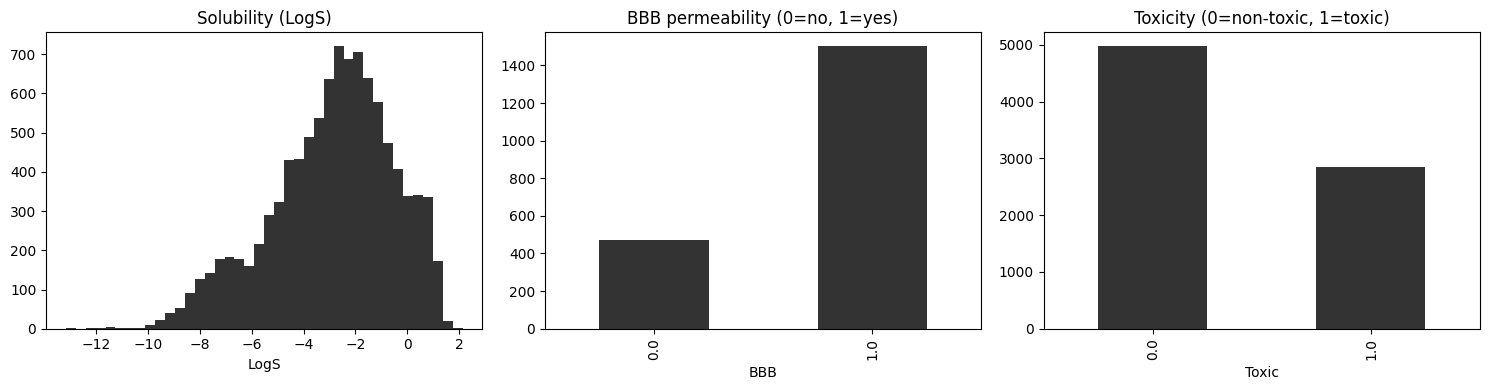

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(merged["LogS"].dropna(), bins=40, color="#333333")
axes[0].set_title("Solubility (LogS)")
axes[0].set_xlabel("LogS")

merged["BBB"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#333333")
axes[1].set_title("BBB permeability (0=no, 1=yes)")

merged["Toxic"].value_counts().sort_index().plot(kind="bar", ax=axes[2], color="#333333")
axes[2].set_title("Toxicity (0=non-toxic, 1=toxic)")

plt.tight_layout()
plt.show()


## 5. Train / validation / test split

A single 70 / 15 / 15 split across all ~16k molecules. Because labels are sparse, each task's
loss and metrics are only ever computed over the rows that actually have that label.


In [9]:
train_df, test_df = train_test_split(merged, test_size=0.15, random_state=SEED)
train_df, val_df  = train_test_split(train_df, test_size=0.1765, random_state=SEED)  # -> ~15% of total

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[FEATURES].values)
X_val   = scaler.transform(val_df[FEATURES].values)
X_test  = scaler.transform(test_df[FEATURES].values)


Train: 11504  Val: 2466  Test: 2466


## 6. Multi-task network

One shared trunk (two hidden layers with BatchNorm + Dropout) feeds three small output heads:

- **Solubility head** &rarr; single linear output (regression)
- **BBB head** &rarr; single logit (binary classification)
- **Toxicity head** &rarr; single logit (binary classification)

The shared trunk is what makes this a genuine multi-task model: features useful for one property
(e.g. LogP, TPSA) inform the others through the same learned representation, rather than training
three unrelated models from scratch.


In [10]:
class MultiTaskNet(nn.Module):
    def __init__(self, n_features, hidden=(128, 64)):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(n_features, hidden[0]),
            nn.ReLU(),
            nn.BatchNorm1d(hidden[0]),
            nn.Dropout(0.2),
            nn.Linear(hidden[0], hidden[1]),
            nn.ReLU(),
            nn.BatchNorm1d(hidden[1]),
        )
        self.solubility_head = nn.Linear(hidden[1], 1)
        self.bbb_head = nn.Linear(hidden[1], 1)
        self.tox_head = nn.Linear(hidden[1], 1)

    def forward(self, x):
        h = self.trunk(x)
        return (
            self.solubility_head(h).squeeze(-1),
            self.bbb_head(h).squeeze(-1),
            self.tox_head(h).squeeze(-1),
        )

def make_targets(d):
    def col(name):
        vals = d[name].values.astype(np.float32)
        mask = (~d[name].isna()).values.astype(np.float32)
        return np.nan_to_num(vals, nan=0.0), mask
    logs, logs_mask = col("LogS")
    bbb, bbb_mask   = col("BBB")
    tox, tox_mask   = col("Toxic")
    return logs, logs_mask, bbb, bbb_mask, tox, tox_mask

def to_tensors(X, d):
    logs, logs_m, bbb, bbb_m, tox, tox_m = make_targets(d)
    return (
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(logs), torch.tensor(logs_m),
        torch.tensor(bbb), torch.tensor(bbb_m),
        torch.tensor(tox), torch.tensor(tox_m),
    )

Xtr, logs_tr, logsm_tr, bbb_tr, bbbm_tr, tox_tr, toxm_tr = to_tensors(X_train, train_df)
Xva, logs_va, logsm_va, bbb_va, bbbm_va, tox_va, toxm_va = to_tensors(X_val, val_df)
Xte, logs_te, logsm_te, bbb_te, bbbm_te, tox_te, toxm_te = to_tensors(X_test, test_df)

def masked_loss(pred, target, mask, lossfn):
    l = lossfn(pred, target) * mask
    denom = mask.sum().clamp(min=1.0)
    return l.sum() / denom

model = MultiTaskNet(n_features=len(FEATURES))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
mse = nn.MSELoss(reduction="none")
bce = nn.BCEWithLogitsLoss(reduction="none")


## 7. Training loop

In [11]:
N_EPOCHS = 80
BATCH_SIZE = 256
n = Xtr.shape[0]

history = {"train_loss": [], "val_sol_mse": [], "val_bbb_bce": [], "val_tox_bce": []}

for epoch in range(N_EPOCHS):
    model.train()
    perm = torch.randperm(n)
    total_loss = 0.0

    for i in range(0, n, BATCH_SIZE):
        idx = perm[i:i + BATCH_SIZE]
        optimizer.zero_grad()

        p_logs, p_bbb, p_tox = model(Xtr[idx])
        loss_s = masked_loss(p_logs, logs_tr[idx], logsm_tr[idx], mse)
        loss_b = masked_loss(p_bbb, bbb_tr[idx], bbbm_tr[idx], bce)
        loss_t = masked_loss(p_tox, tox_tr[idx], toxm_tr[idx], bce)
        loss = loss_s + loss_b + loss_t

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(idx)

    model.eval()
    with torch.no_grad():
        p_logs, p_bbb, p_tox = model(Xva)
        vs = masked_loss(p_logs, logs_va, logsm_va, mse).item()
        vb = masked_loss(p_bbb, bbb_va, bbbm_va, bce).item()
        vt = masked_loss(p_tox, tox_va, toxm_va, bce).item()

    history["train_loss"].append(total_loss / n)
    history["val_sol_mse"].append(vs)
    history["val_bbb_bce"].append(vb)
    history["val_tox_bce"].append(vt)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d} | train_loss={total_loss/n:.4f} | "
              f"val_sol_mse={vs:.4f}  val_bbb_bce={vb:.4f}  val_tox_bce={vt:.4f}")


Epoch   1 | train_loss=11.4774 | val_sol_mse=9.3901  val_bbb_bce=0.5008  val_tox_bce=0.6522


Epoch  10 | train_loss=2.4462 | val_sol_mse=1.4072  val_bbb_bce=0.4123  val_tox_bce=0.5897


Epoch  20 | train_loss=2.2495 | val_sol_mse=1.3980  val_bbb_bce=0.3995  val_tox_bce=0.5797


Epoch  30 | train_loss=2.1556 | val_sol_mse=1.3150  val_bbb_bce=0.3923  val_tox_bce=0.5742


Epoch  40 | train_loss=2.0825 | val_sol_mse=1.3054  val_bbb_bce=0.3849  val_tox_bce=0.5713


Epoch  50 | train_loss=2.0083 | val_sol_mse=1.2462  val_bbb_bce=0.3879  val_tox_bce=0.5756


Epoch  60 | train_loss=1.9449 | val_sol_mse=1.3002  val_bbb_bce=0.3788  val_tox_bce=0.5703


Epoch  70 | train_loss=1.9263 | val_sol_mse=1.2848  val_bbb_bce=0.3831  val_tox_bce=0.5705


Epoch  80 | train_loss=1.9117 | val_sol_mse=1.2631  val_bbb_bce=0.3856  val_tox_bce=0.5706


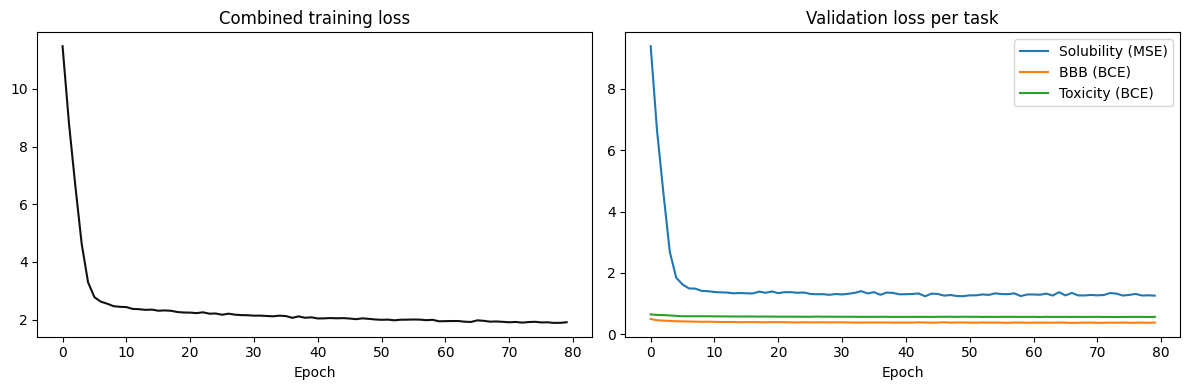

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], color="#111111")
axes[0].set_title("Combined training loss")
axes[0].set_xlabel("Epoch")

axes[1].plot(history["val_sol_mse"], label="Solubility (MSE)")
axes[1].plot(history["val_bbb_bce"], label="BBB (BCE)")
axes[1].plot(history["val_tox_bce"], label="Toxicity (BCE)")
axes[1].set_title("Validation loss per task")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Test-set evaluation

Each task is scored only on the test molecules that actually carry that label.


In [13]:
model.eval()
with torch.no_grad():
    p_logs, p_bbb, p_tox = model(Xte)

# --- Solubility ---
m = logsm_te.numpy().astype(bool)
y_true, y_pred = logs_te.numpy()[m], p_logs.numpy()[m]
mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred) ** 0.5
r2 = r2_score(y_true, y_pred)
print(f"Solubility   (n={m.sum():4d})  MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}")

# --- BBB ---
m = bbbm_te.numpy().astype(bool)
probs = torch.sigmoid(p_bbb).numpy()[m]
preds = (probs >= 0.5).astype(int)
y_true = bbb_te.numpy()[m]
acc = accuracy_score(y_true, preds)
auc = roc_auc_score(y_true, probs)
print(f"BBB          (n={m.sum():4d})  Accuracy={acc:.4f}  ROC-AUC={auc:.4f}")

# --- Toxicity ---
m = toxm_te.numpy().astype(bool)
probs = torch.sigmoid(p_tox).numpy()[m]
preds = (probs >= 0.5).astype(int)
y_true = tox_te.numpy()[m]
acc = accuracy_score(y_true, preds)
auc = roc_auc_score(y_true, probs)
print(f"Toxicity     (n={m.sum():4d})  Accuracy={acc:.4f}  ROC-AUC={auc:.4f}")


Solubility   (n=1484)  MAE=0.8187  RMSE=1.2042  R2=0.7511
BBB          (n= 296)  Accuracy=0.8953  ROC-AUC=0.8999
Toxicity     (n=1171)  Accuracy=0.7472  ROC-AUC=0.7798


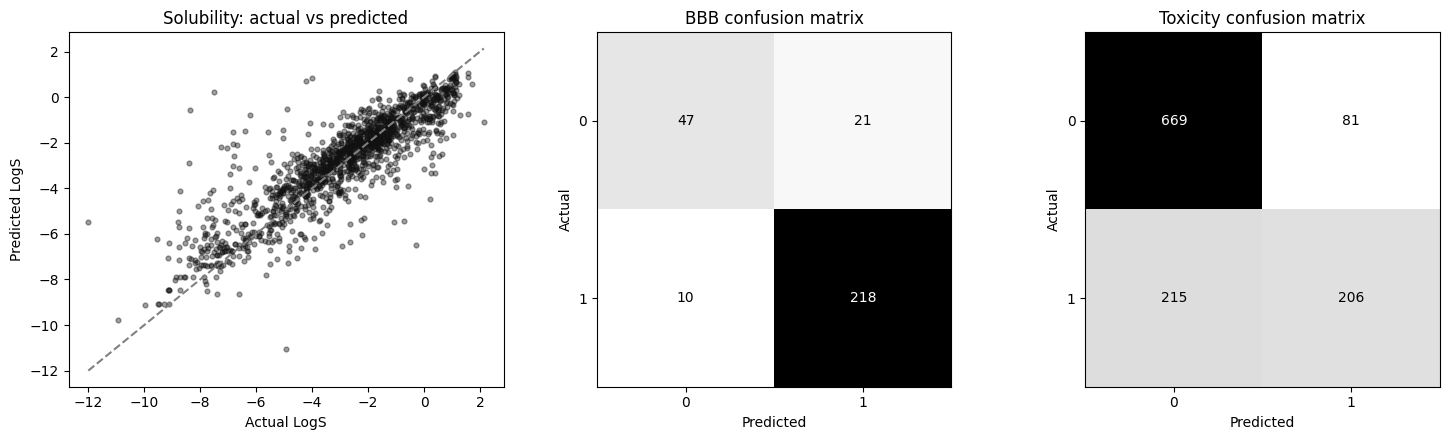

In [14]:
# Actual vs predicted solubility, and confusion matrices for the two classifiers
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

m = logsm_te.numpy().astype(bool)
axes[0].scatter(logs_te.numpy()[m], p_logs.numpy()[m], alpha=0.4, s=12, color="#111111")
lims = [min(logs_te.numpy()[m].min(), p_logs.numpy()[m].min()),
        max(logs_te.numpy()[m].max(), p_logs.numpy()[m].max())]
axes[0].plot(lims, lims, "--", color="gray")
axes[0].set_title("Solubility: actual vs predicted")
axes[0].set_xlabel("Actual LogS")
axes[0].set_ylabel("Predicted LogS")

for ax, name, y_true, probs_full, mask in [
    (axes[1], "BBB", bbb_te.numpy(), torch.sigmoid(p_bbb).numpy(), bbbm_te.numpy().astype(bool)),
    (axes[2], "Toxicity", tox_te.numpy(), torch.sigmoid(p_tox).numpy(), toxm_te.numpy().astype(bool)),
]:
    yt = y_true[mask]
    yp = (probs_full[mask] >= 0.5).astype(int)
    cm = confusion_matrix(yt, yp)
    ax.imshow(cm, cmap="Greys")
    ax.set_title(f"{name} confusion matrix")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center",
                color="white" if v > cm.max() / 2 else "black")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


## 9. Save the trained artifacts

Three files go into `models/`, replacing the old single-task `.pkl` files:

- `multitask_model.pt` &mdash; the trained network's weights
- `multitask_scaler.pkl` &mdash; the `StandardScaler` fit on training descriptors (needed at inference time)
- `multitask_config.json` &mdash; feature list + architecture, so `predict.py` can rebuild the network shape

These three, together, fully define the model for the Flask app.


In [15]:
import json

torch.save(model.state_dict(), "../models/multitask_model.pt")
joblib.dump(scaler, "../models/multitask_scaler.pkl")

config = {
    "features": FEATURES,
    "hidden": [128, 64],
    "tasks": ["LogS", "BBB", "Toxic"],
}
with open("../models/multitask_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved:")
print(" - models/multitask_model.pt")
print(" - models/multitask_scaler.pkl")
print(" - models/multitask_config.json")


Saved:
 - models/multitask_model.pt
 - models/multitask_scaler.pkl
 - models/multitask_config.json


## 10. Quick sanity check on new molecules

Try the model on a few SMILES it has never seen, the same way `predict.py` will call it in the Flask app.


In [16]:
def predict_one(smiles):
    d = calc_descriptors(smiles)
    if d is None:
        raise ValueError(f"Invalid SMILES: {smiles}")
    x = np.array([[d[f] for f in FEATURES]])
    x = scaler.transform(x)
    x = torch.tensor(x, dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        p_logs, p_bbb, p_tox = model(x)

    return {
        "smiles": smiles,
        "predicted_logS": round(float(p_logs.item()), 3),
        "bbb_permeant_prob": round(float(torch.sigmoid(p_bbb).item()), 3),
        "toxic_prob": round(float(torch.sigmoid(p_tox).item()), 3),
        "descriptors": {k: v for k, v in d.items() if k != "canonical_smiles"},
    }

for smi in ["CCO", "c1ccccc1", "CC(=O)Oc1ccccc1C(=O)O", "CN1CCC[C@H]1c1cccnc1"]:
    print(predict_one(smi))
    print()


{'smiles': 'CCO', 'predicted_logS': 0.914, 'bbb_permeant_prob': 0.991, 'toxic_prob': 0.079, 'descriptors': {'Molecular_Weight': 46.069, 'LogP': -0.0014000000000000123, 'TPSA': 20.23, 'H_Bond_Donors': 1, 'H_Bond_Acceptors': 1, 'Rotatable_Bonds': 0, 'Ring_Count': 0, 'Heavy_Atom_Count': 3, 'Fraction_CSP3': 1.0, 'Aromatic_Rings': 0, 'Molar_Refractivity': 12.759800000000002, 'Num_Heteroatoms': 1}}

{'smiles': 'c1ccccc1', 'predicted_logS': -1.592, 'bbb_permeant_prob': 0.971, 'toxic_prob': 0.102, 'descriptors': {'Molecular_Weight': 78.11399999999999, 'LogP': 1.6866, 'TPSA': 0.0, 'H_Bond_Donors': 0, 'H_Bond_Acceptors': 0, 'Rotatable_Bonds': 0, 'Ring_Count': 1, 'Heavy_Atom_Count': 6, 'Fraction_CSP3': 0.0, 'Aromatic_Rings': 1, 'Molar_Refractivity': 26.441999999999993, 'Num_Heteroatoms': 0}}

{'smiles': 'CC(=O)Oc1ccccc1C(=O)O', 'predicted_logS': -2.225, 'bbb_permeant_prob': 0.74, 'toxic_prob': 0.225, 'descriptors': {'Molecular_Weight': 180.15899999999996, 'LogP': 1.3101, 'TPSA': 63.60000000000001

## Notes / next steps

- The **Toxicity** label here is a coarse "any Tox21 assay fired" aggregate. If you want finer-grained
  toxicity info (e.g. specifically hepatotoxicity or cardiotoxicity risk), swap in one or more of the
  individual `assay_cols` as extra output heads instead of collapsing them.
- **BBB** has the fewest labeled examples (~2,000) of the three tasks, so its head benefits the most
  from sharing the trunk with the much larger solubility task &mdash; a nice practical demonstration of
  why multi-task learning helps on small/imbalanced properties.
- To retrain with even more data, AqSolDB, BBBP, and Tox21 can each be swapped for larger/newer
  MoleculeNet-style datasets without changing anything else in this notebook &mdash; only the three
  download URLs in Section 2 need to change.
